### Module 3: Unsupervised Learning &nbsp;|&nbsp; Module 4: Reinforcement Learning

---
## Agenda

**Module 3 — Unsupervised Learning**
1. Clustering (K-Means, Elbow Method, Hierarchical Clustering, DBSCAN, Gaussian Mixture Models)
2. Dimensionality Reduction (PCA, t-SNE, LLE/Isomap)
3. Association Rule Mining (Apriori, FP-Growth)

**Module 4 — Reinforcement Learning**
1. Model-Based Methods (MDPs, Bellman Equation, Value Iteration)
2. Model-Free Methods (Q-Learning, SARSA, Monte Carlo, and a taste of policy-gradient methods)


## 🔧 Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_classification, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

print("✅ Libraries loaded. Ready to go!")


✅ Libraries loaded. Ready to go!


---
# 📦 Module 3: Unsupervised Learning

Unsupervised learning finds structure in data that has **no labels**. It splits into three big ideas:
- **Clustering** — group similar points together
- **Dimensionality Reduction** — compress many features into fewer, while keeping the important information
- **Association Rule Mining** — find "if this, then that" patterns (e.g. market baskets)

## 3.1 Clustering

### Synthetic dataset: customer segments (spending behavior)

We'll simulate customers described by **annual income** and **spending score** — a classic
segmentation example — with three natural-ish groups.


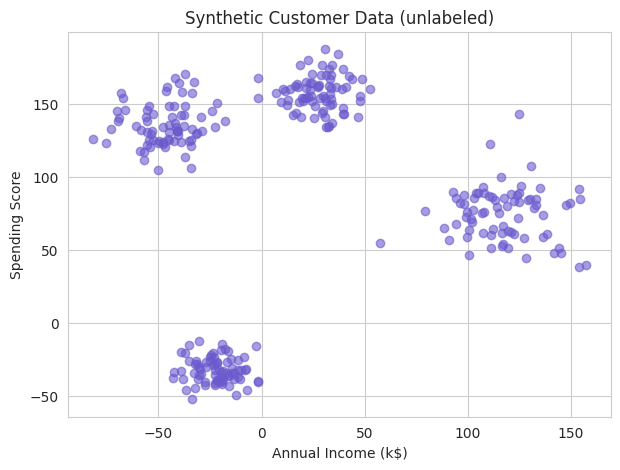

In [2]:
X_blobs, y_true_blobs = make_blobs(
    n_samples=300, centers=4, cluster_std=[1.0, 1.5, 0.8, 1.2],
    random_state=RANDOM_STATE
)
income = X_blobs[:, 0] * 12 + 60          # thousands of $ per year
spending_score = X_blobs[:, 1] * 12 + 50  # 0-100 scale

customers = pd.DataFrame({"annual_income_k": income, "spending_score": spending_score})

plt.scatter(customers["annual_income_k"], customers["spending_score"], alpha=0.6, color="slateblue")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Synthetic Customer Data (unlabeled)")
plt.show()


### K-Means Clustering

K-Means partitions data into **k** clusters by repeatedly assigning points to the nearest centroid,
then moving centroids to the mean of their assigned points. Scikit-learn's default initialization
is already **K-Means++**, which picks smarter starting centroids (spread apart) instead of fully
random ones — this converges faster and more reliably than plain random init.

**🧪 Try it yourself:** change `init="k-means++"` to `init="random"` and re-run a few times — notice
how random init occasionally produces a worse clustering.


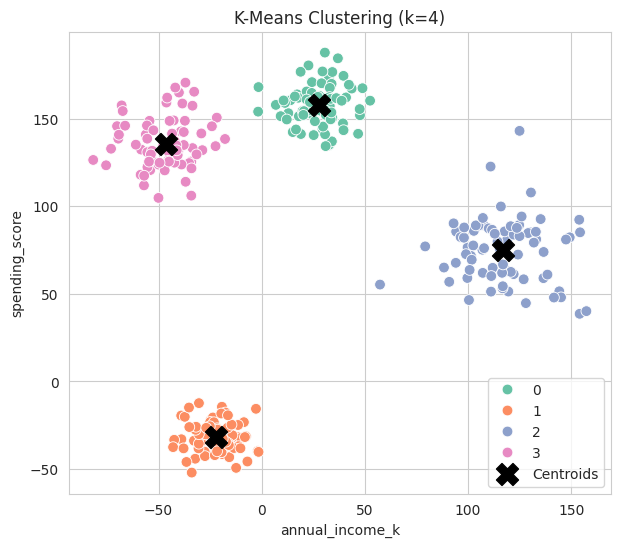

In [3]:
X_cust = customers.values

kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE)
customers["cluster_kmeans"] = kmeans.fit_predict(X_cust)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=customers, x="annual_income_k", y="spending_score",
                hue="cluster_kmeans", palette="Set2", s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="X", s=250, color="black", label="Centroids")
plt.title("K-Means Clustering (k=4)")
plt.legend()
plt.show()


### Elbow Method — choosing the right k

We don't always know the right number of clusters in advance. The **elbow method** plots inertia
(within-cluster sum of squares) against `k` — the "elbow" point is a good candidate for k.


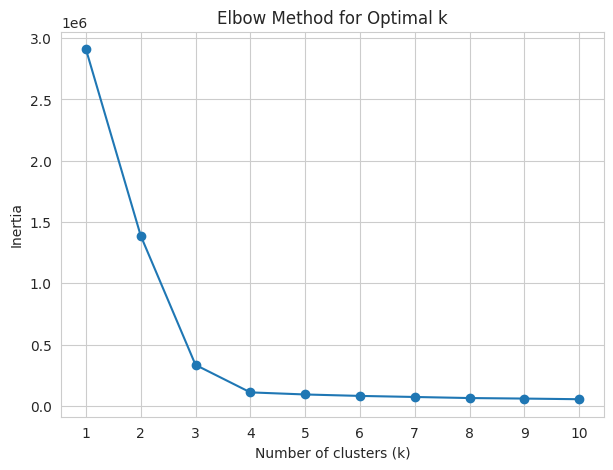

In [4]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_cust)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.show()


### Hierarchical Clustering (Agglomerative + Dendrogram)

Hierarchical clustering builds a tree of merges: it starts with every point as its own cluster,
then repeatedly merges the two closest clusters until only one remains. The **dendrogram** lets you
pick the number of clusters *after* seeing the whole hierarchy, by cutting the tree at a chosen height.


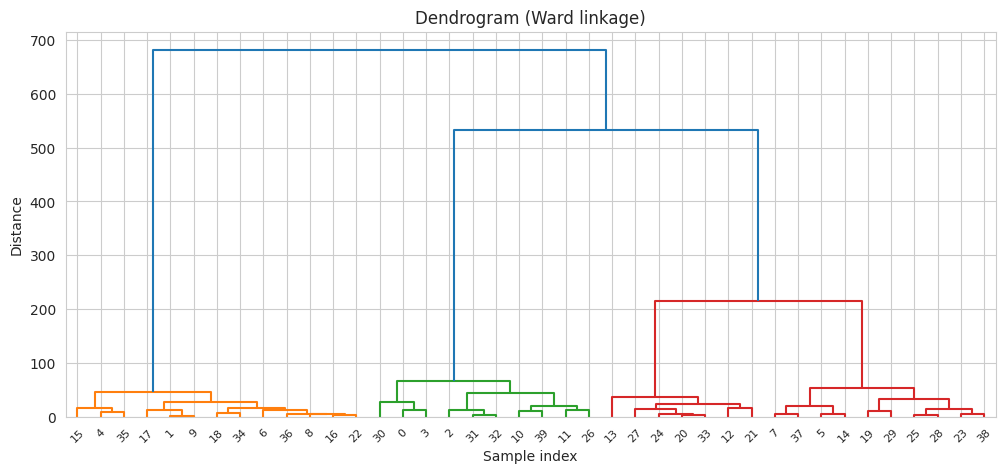

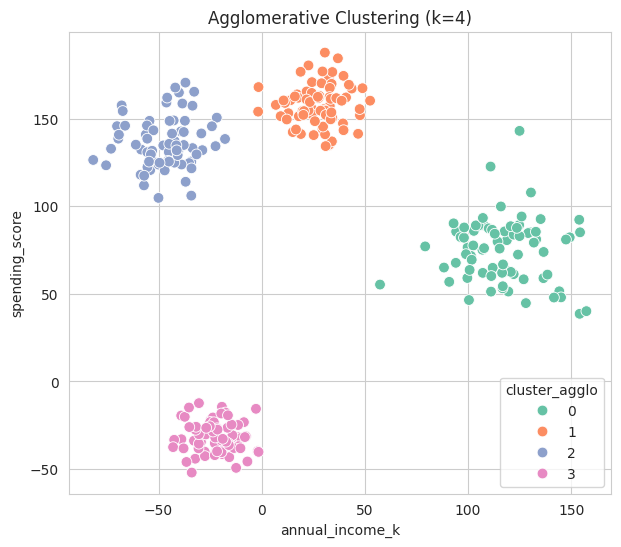

In [5]:
# Use a smaller sample so the dendrogram stays readable
sample_idx = np.random.choice(len(X_cust), 40, replace=False)
X_sample = X_cust[sample_idx]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

agglo = AgglomerativeClustering(n_clusters=4, linkage="ward")
customers["cluster_agglo"] = agglo.fit_predict(X_cust)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=customers, x="annual_income_k", y="spending_score",
                hue="cluster_agglo", palette="Set2", s=60)
plt.title("Agglomerative Clustering (k=4)")
plt.show()


### DBSCAN — Density-Based Clustering

K-Means assumes round, evenly-sized clusters. Real data is often shaped in curves or rings.
**DBSCAN** groups points that are densely packed together and marks sparse points as **noise/outliers**
— no need to pre-specify the number of clusters. Let's see K-Means fail on curved data, then fix it
with DBSCAN.


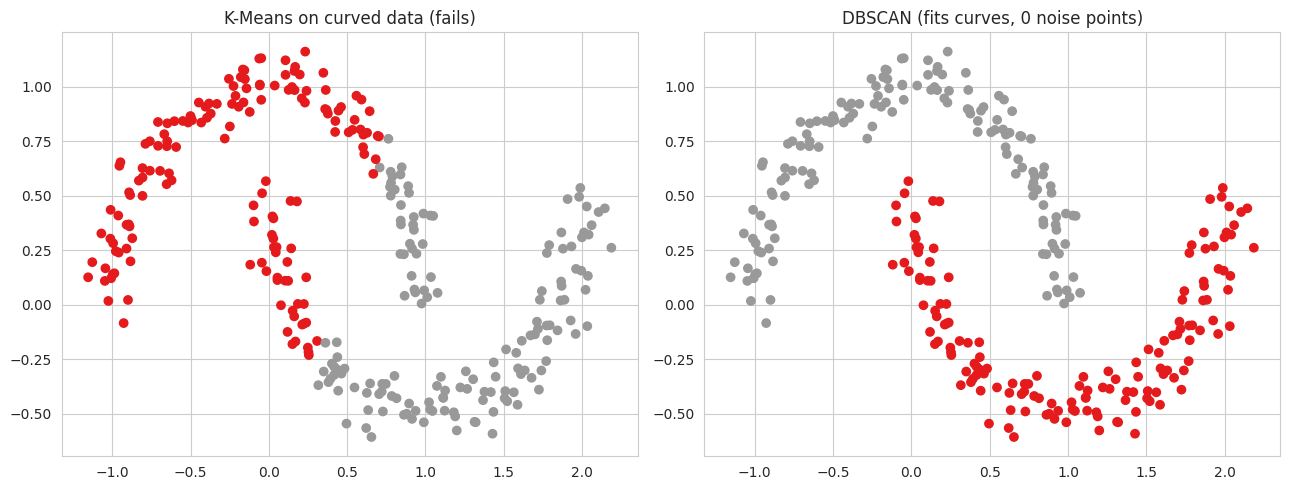

In [6]:
X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Means struggles here
km_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
km_labels = km_moons.fit_predict(X_moons)
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=km_labels, cmap="Set1")
axes[0].set_title("K-Means on curved data (fails)")

# DBSCAN handles it
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X_moons)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=db_labels, cmap="Set1")
n_noise = (db_labels == -1).sum()
axes[1].set_title(f"DBSCAN (fits curves, {n_noise} noise points)")

plt.tight_layout()
plt.show()


**🧪 Try it yourself:** shrink `eps` from `0.2` to `0.1` — more points get marked as noise (label
`-1`). Grow it to `0.4` — clusters start merging into one. `eps` is DBSCAN's most important dial.


### Gaussian Mixture Models (GMM) — Soft Clustering

K-Means makes a **hard** assignment (each point belongs to exactly one cluster). A **Gaussian
Mixture Model** assumes clusters are Gaussian "blobs" and gives each point a **probability** of
belonging to each cluster — useful when clusters overlap.


Soft cluster probabilities for the first 5 customers:
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


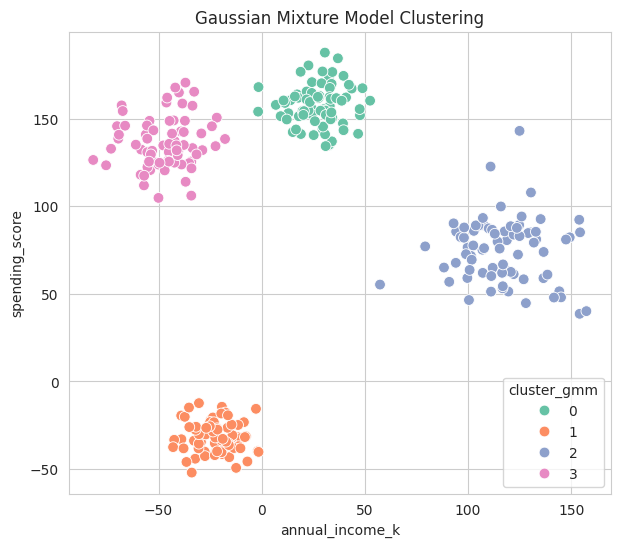

In [7]:
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm.fit(X_cust)
customers["cluster_gmm"] = gmm.predict(X_cust)
probs = gmm.predict_proba(X_cust)

print("Soft cluster probabilities for the first 5 customers:")
print(np.round(probs[:5], 2))

plt.figure(figsize=(7, 6))
sns.scatterplot(data=customers, x="annual_income_k", y="spending_score",
                hue="cluster_gmm", palette="Set2", s=60)
plt.title("Gaussian Mixture Model Clustering")
plt.show()


> **Note on other clustering variants mentioned in the syllabus:** K-Modes (for purely categorical
> data), Fuzzy C-Means, DPMMs, Divisive clustering, Affinity Propagation, and OPTICS all follow the
> same core ideas as the algorithms above (centroid-based, distribution-based, or density-based) —
> worth a slide/discussion, but skipped here for time.


## 3.2 Dimensionality Reduction

**Synthetic dataset:** a 10-feature dataset where only a few features actually carry signal — a
realistic scenario where dimensionality reduction helps visualization and can speed up modeling.


In [8]:
X_high, y_high = make_classification(
    n_samples=400, n_features=10, n_informative=4, n_redundant=3,
    n_clusters_per_class=1, n_classes=3, random_state=RANDOM_STATE
)
print("Original shape:", X_high.shape)


Original shape: (400, 10)


### PCA (Principal Component Analysis)

PCA finds new axes (principal components) that capture the most **variance** in the data, letting
us compress 10 features down to 2 for visualization while keeping most of the information.


Explained variance ratio: [0.438 0.219]
Total variance captured by 2 components: 65.7%


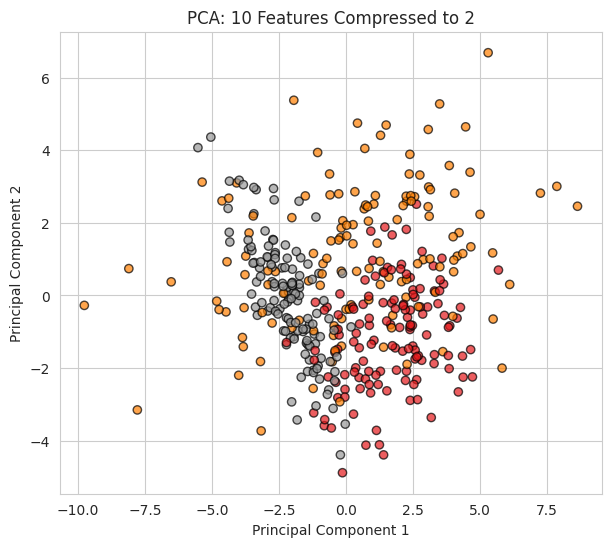

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_high)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_high, cmap="Set1", alpha=0.7, edgecolor="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 10 Features Compressed to 2")
plt.show()


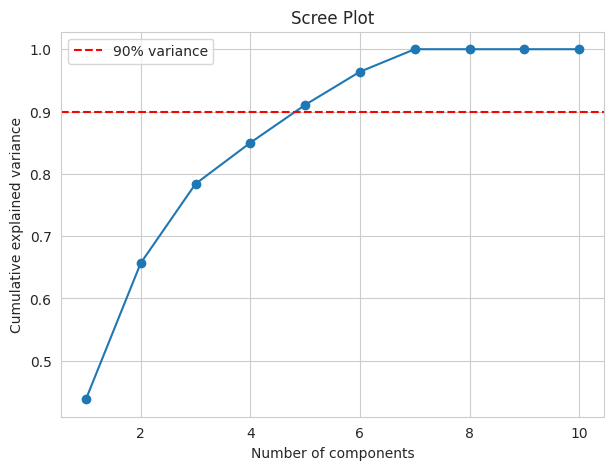

In [10]:
# Scree plot: how much variance each component explains
pca_full = PCA(random_state=RANDOM_STATE).fit(X_high)
plt.plot(range(1, 11), np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Scree Plot")
plt.axhline(0.9, linestyle="--", color="red", label="90% variance")
plt.legend()
plt.show()


### t-SNE (t-distributed Stochastic Neighbor Embedding)

PCA preserves **global** variance, but is linear. **t-SNE** is non-linear and focuses on preserving
**local neighborhoods** — often produces more visually distinct clusters, but distances between
clusters aren't meaningful and it's slower/more randomness-sensitive than PCA.


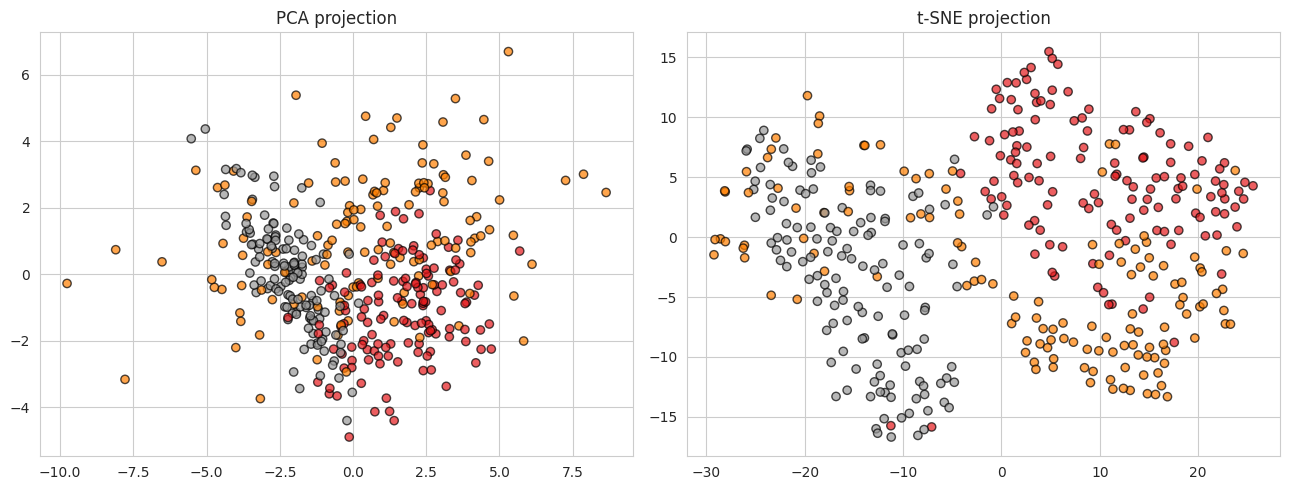

In [11]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_high)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_high, cmap="Set1", alpha=0.7, edgecolor="k")
axes[0].set_title("PCA projection")
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_high, cmap="Set1", alpha=0.7, edgecolor="k")
axes[1].set_title("t-SNE projection")
plt.tight_layout()
plt.show()


### Manifold Learning — Isomap & LLE on a Swiss Roll

PCA and even t-SNE can struggle with data that lies on a curved **manifold**. The classic teaching
example is the "Swiss Roll" — a 3D S-shaped curl that is really a 2D sheet rolled up. **Isomap** and
**Locally Linear Embedding (LLE)** are built to "unroll" exactly this kind of structure.


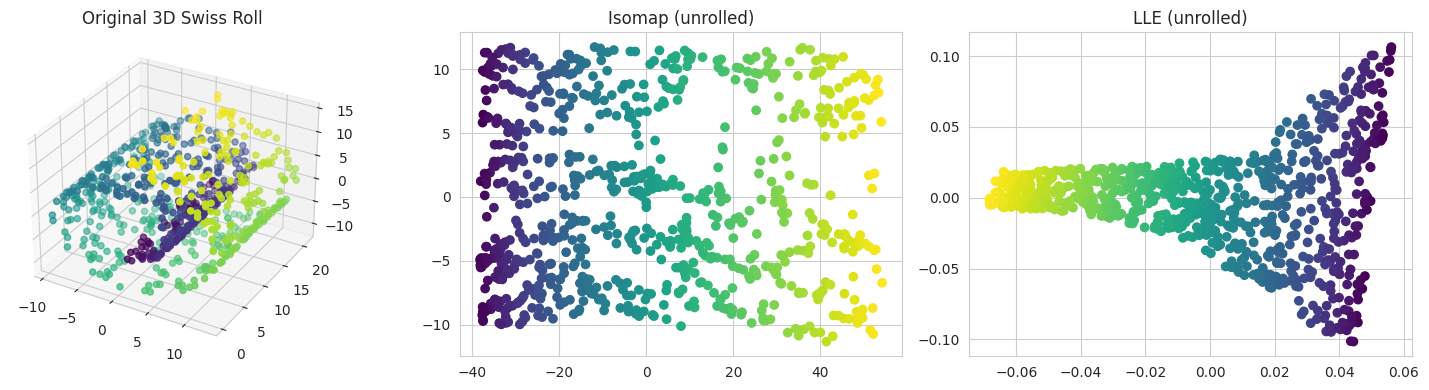

In [12]:
X_roll, color = make_swiss_roll(n_samples=800, noise=0.05, random_state=RANDOM_STATE)

fig = plt.figure(figsize=(15, 4))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=color, cmap="viridis")
ax1.set_title("Original 3D Swiss Roll")

isomap = Isomap(n_neighbors=10, n_components=2)
X_iso = isomap.fit_transform(X_roll)
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_iso[:, 0], X_iso[:, 1], c=color, cmap="viridis")
ax2.set_title("Isomap (unrolled)")

lle = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=RANDOM_STATE)
X_lle = lle.fit_transform(X_roll)
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap="viridis")
ax3.set_title("LLE (unrolled)")

plt.tight_layout()
plt.show()


> **Note:** NMF (Non-negative Matrix Factorization) and ICA (Independent Component Analysis) follow
> the same "compress features" goal as PCA, but with different constraints — NMF requires non-negative
> data (great for text/image counts), ICA looks for statistically independent signals (great for
> separating mixed audio signals, the classic "cocktail party problem").


## 3.3 Association Rule Mining

**Synthetic dataset:** simulated grocery-store shopping carts (market basket data) — a set of
transactions, each containing a handful of items.


In [13]:
# mlxtend isn't preinstalled in Colab by default — this installs it (one-time, ~few seconds)
!pip install -q mlxtend


In [14]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

rng = np.random.default_rng(RANDOM_STATE)

item_catalog = ["bread", "milk", "eggs", "butter", "cheese", "beer", "diapers", "coffee", "sugar", "tea"]

# Build transactions with some deliberate co-occurrence patterns baked in
# (bread+butter, beer+diapers, coffee+sugar tend to appear together)
transactions = []
for _ in range(300):
    basket = set(rng.choice(item_catalog, size=rng.integers(2, 6), replace=False))
    if rng.random() < 0.5:
        basket.update(["bread", "butter"])
    if rng.random() < 0.3:
        basket.update(["beer", "diapers"])
    if rng.random() < 0.4:
        basket.update(["coffee", "sugar"])
    transactions.append(list(basket))

print("Example transactions:")
for t in transactions[:5]:
    print(" -", t)


Example transactions:
 - ['sugar', 'coffee', np.str_('diapers'), np.str_('tea')]
 - [np.str_('sugar'), np.str_('coffee'), np.str_('beer'), np.str_('diapers'), 'butter', 'bread']
 - [np.str_('diapers'), np.str_('cheese'), np.str_('eggs'), np.str_('tea'), np.str_('butter'), 'bread']
 - [np.str_('diapers'), np.str_('coffee')]
 - ['sugar', 'coffee', np.str_('cheese'), np.str_('eggs'), np.str_('butter'), np.str_('milk'), np.str_('bread')]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Apriori Algorithm

Apriori finds **frequent itemsets** (combinations of items that appear together often enough), then
derives **association rules** like *"if a customer buys beer, they also buy diapers"* — scored by:
- **Support**: how often the itemset appears overall
- **Confidence**: P(buy diapers | bought beer)
- **Lift**: how much more likely diapers are bought *given* beer, vs. buying diapers on its own (lift > 1 = positive association)


In [15]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.08, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
print("Top frequent itemsets:")
print(frequent_itemsets.head(10))

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)
print("\nTop association rules:")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


Top frequent itemsets:
     support          itemsets
2   0.656667          (butter)
1   0.653333           (bread)
4   0.646667          (coffee)
8   0.636667           (sugar)
19  0.550000   (bread, butter)
0   0.540000            (beer)
5   0.513333         (diapers)
43  0.500000   (sugar, coffee)
28  0.420000  (coffee, butter)
21  0.416667   (coffee, bread)

Top association rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
755,"(beer, coffee, bread)","(sugar, diapers, butter)",0.1,0.461538,2.197802
750,"(sugar, diapers, butter)","(beer, coffee, bread)",0.1,0.476190,2.197802
754,"(beer, coffee, butter)","(sugar, diapers, bread)",0.1,0.468750,2.130682
756,"(diapers, coffee, butter)","(beer, sugar, bread)",0.1,0.468750,2.130682
749,"(beer, sugar, bread)","(diapers, coffee, butter)",0.1,0.454545,2.130682
751,"(sugar, diapers, bread)","(beer, coffee, butter)",0.1,0.454545,2.130682
767,"(sugar, bread)","(beer, diapers, coffee, butter)",0.1,0.247934,2.010275
738,"(beer, diapers, coffee, butter)","(sugar, bread)",0.1,0.810811,2.010275
748,"(beer, sugar, butter)","(diapers, coffee, bread)",0.1,0.447761,2.004901
757,"(diapers, coffee, bread)","(beer, sugar, butter)",0.1,0.447761,2.004901


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### FP-Growth — a faster alternative to Apriori

Apriori repeatedly re-scans the data to test candidate itemsets, which gets slow on large datasets.
**FP-Growth** compresses the data into a tree structure and finds the same frequent itemsets without
that repeated scanning — same result, less computation.


In [16]:
frequent_itemsets_fp = fpgrowth(basket_df, min_support=0.08, use_colnames=True)
print(f"Apriori found {len(frequent_itemsets)} itemsets, FP-Growth found {len(frequent_itemsets_fp)} itemsets")
print("(Should match — they're two algorithms solving the exact same problem)")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Apriori found 206 itemsets, FP-Growth found 206 itemsets
(Should match — they're two algorithms solving the exact same problem)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

> **Note:** ECLAT is a third algorithm for the same task, using a vertical (item → transaction-list)
> data format instead of horizontal scans — conceptually similar goal, different bookkeeping.


---
# 🎮 Module 4: Reinforcement Learning

Reinforcement Learning (RL) is different from Modules 1-3: there's no fixed dataset. Instead, an
**agent** interacts with an **environment**, taking **actions**, receiving **rewards**, and learning
a **policy** (what action to take in each state) that maximizes long-term reward.

We'll build a tiny **GridWorld** — a classic teaching environment — and use it for every algorithm
in this module so you can directly compare approaches.


### Our synthetic environment: GridWorld

A 4×4 grid. The agent starts at the top-left, must reach the goal (bottom-right, reward **+10**),
while avoiding a trap cell (reward **-10**). Every other step costs **-1** (to encourage short paths).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

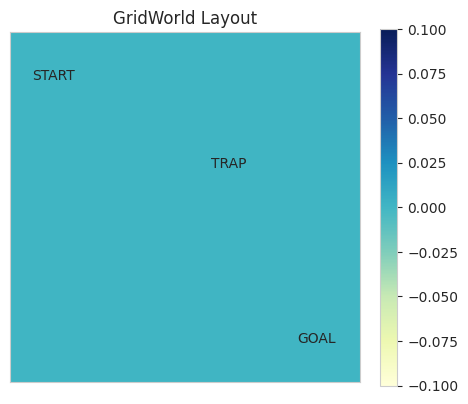

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
GRID_SIZE = 4
GOAL = (3, 3)
TRAP = (1, 2)
START = (0, 0)
ACTIONS = ["up", "down", "left", "right"]
ACTION_DELTAS = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

def step(state, action):
    """Returns (next_state, reward, done) for taking `action` in `state`."""
    if state == GOAL or state == TRAP:
        return state, 0, True

    dr, dc = ACTION_DELTAS[action]
    r, c = state[0] + dr, state[1] + dc
    r = max(0, min(GRID_SIZE - 1, r))
    c = max(0, min(GRID_SIZE - 1, c))
    next_state = (r, c)

    if next_state == GOAL:
        return next_state, 10, True
    elif next_state == TRAP:
        return next_state, -10, True
    else:
        return next_state, -1, False

def render_grid(values=None, policy=None, title=""):
    fig, ax = plt.subplots(figsize=(5, 5))
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    if values is not None:
        grid = values.copy()
    im = ax.imshow(grid, cmap="YlGnBu")

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            label = ""
            if (r, c) == GOAL:
                label = "GOAL"
            elif (r, c) == TRAP:
                label = "TRAP"
            elif (r, c) == START:
                label = "START"
            if values is not None:
                label += f"\n{values[r, c]:.1f}"
            if policy is not None and (r, c) not in (GOAL, TRAP):
                arrow = {"up": "↑", "down": "↓", "left": "←", "right": "→"}[policy[(r, c)]]
                label += f"\n{arrow}"
            ax.text(c, r, label.strip(), ha="center", va="center", fontsize=10)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

render_grid(title="GridWorld Layout")


## 4.1 Model-Based Methods

"Model-based" means the agent **knows** the environment's rules (transitions and rewards) up front
and can plan directly, without needing to explore by trial and error.

### The Bellman Equation

The value of a state V(s) is the expected reward from being in that state and acting optimally
forever after:

`V(s) = max_a [ R(s, a) + γ · V(s') ]`

where `γ` (gamma) is the **discount factor** — how much we value future rewards vs. immediate ones.

### Value Iteration

Value Iteration applies the Bellman equation repeatedly until the value function stops changing,
then reads off the best action in each state.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Value Iteration converged after 7 iterations


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


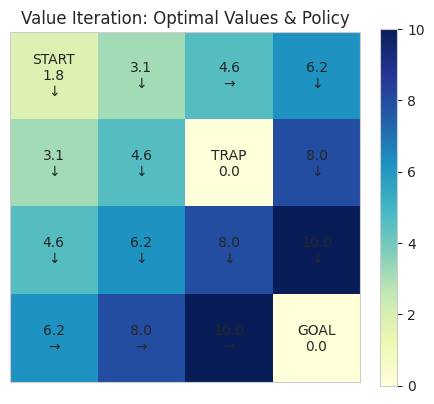

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
GAMMA = 0.9
THETA = 1e-4  # convergence threshold

V = np.zeros((GRID_SIZE, GRID_SIZE))

all_states = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]

iteration = 0
while True:
    delta = 0
    new_V = V.copy()
    for s in all_states:
        if s == GOAL or s == TRAP:
            continue
        action_values = []
        for a in ACTIONS:
            next_s, reward, done = step(s, a)
            action_values.append(reward + GAMMA * V[next_s])
        new_V[s] = max(action_values)
        delta = max(delta, abs(new_V[s] - V[s]))
    V = new_V
    iteration += 1
    if delta < THETA:
        break

print(f"Value Iteration converged after {iteration} iterations")

# Extract the optimal policy from the converged value function
policy = {}
for s in all_states:
    if s == GOAL or s == TRAP:
        continue
    best_action, best_value = None, -np.inf
    for a in ACTIONS:
        next_s, reward, done = step(s, a)
        val = reward + GAMMA * V[next_s]
        if val > best_value:
            best_value, best_action = val, a
    policy[s] = best_action

render_grid(values=V, policy=policy, title="Value Iteration: Optimal Values & Policy")


**🧪 Try it yourself:** lower `GAMMA` to `0.5` and re-run — the agent becomes more short-sighted
and the values near the goal drop off faster with distance.

> **Monte Carlo Tree Search (MCTS)** (used in AlphaGo etc.) is also model-based but instead of
> sweeping over every state like Value Iteration, it selectively simulates promising future
> action-sequences — essential when the state space is too large to enumerate fully (e.g. board games).


## 4.2 Model-Free Methods

Model-free agents **don't** get the transition/reward rules — they must learn purely from
experience by repeatedly acting in the environment and observing outcomes.

### Q-Learning (off-policy)

Q-Learning learns a **Q-table**: the expected value of taking action `a` in state `s`. It updates
using the best possible next action, regardless of what the agent actually does next (hence
"off-policy").


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

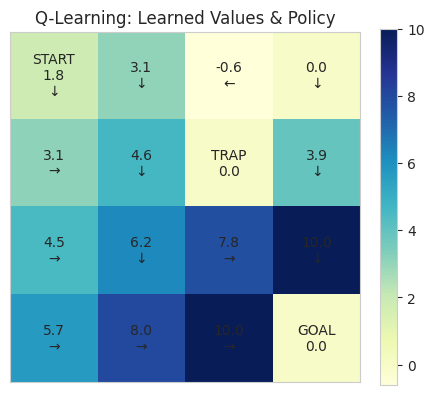

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(ACTIONS)
    q_values = [Q[state][a] for a in ACTIONS]
    return ACTIONS[np.argmax(q_values)]

def train_q_learning(n_episodes=500, alpha=0.1, gamma=0.9, epsilon=0.2):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states}
    rewards_per_episode = []

    for ep in range(n_episodes):
        state = START
        total_reward = 0
        done = False
        steps = 0
        while not done and steps < 50:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, done = step(state, action)
            best_next_q = max(Q[next_state].values())
            # Q-learning update: uses the BEST next action's value (off-policy)
            Q[state][action] += alpha * (reward + gamma * best_next_q - Q[state][action])
            state = next_state
            total_reward += reward
            steps += 1
        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

np.random.seed(RANDOM_STATE)
Q_learned, q_rewards = train_q_learning()

q_policy = {s: ACTIONS[np.argmax([Q_learned[s][a] for a in ACTIONS])]
            for s in all_states if s not in (GOAL, TRAP)}
Q_values_grid = np.array([[max(Q_learned[(r, c)].values()) for c in range(GRID_SIZE)]
                           for r in range(GRID_SIZE)])

render_grid(values=Q_values_grid, policy=q_policy, title="Q-Learning: Learned Values & Policy")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

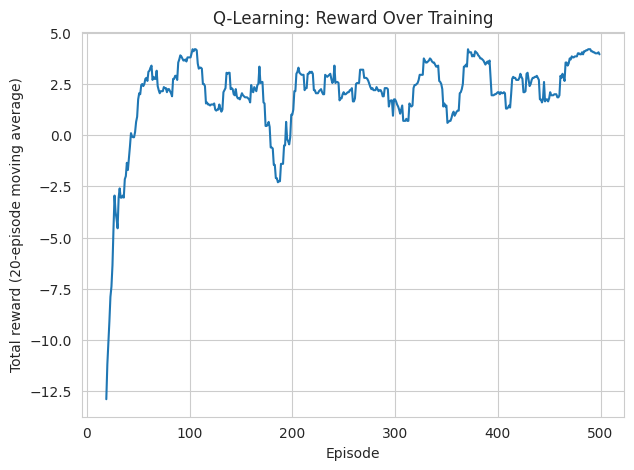

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
plt.plot(pd.Series(q_rewards).rolling(20).mean())
plt.xlabel("Episode")
plt.ylabel("Total reward (20-episode moving average)")
plt.title("Q-Learning: Reward Over Training")
plt.show()


### SARSA (on-policy)

SARSA is almost identical to Q-Learning, but it updates using the value of the action the agent
**actually takes next** (following its own epsilon-greedy policy), not the best possible one — hence
"on-policy". This tends to make SARSA more cautious around risky states (like our TRAP cell).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

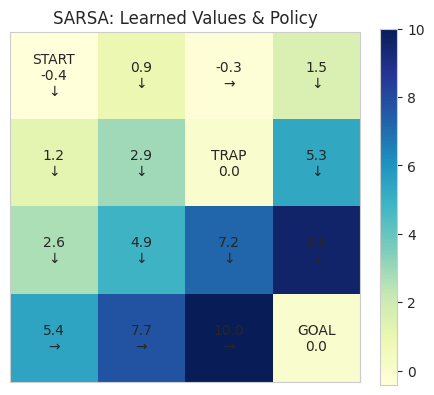

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

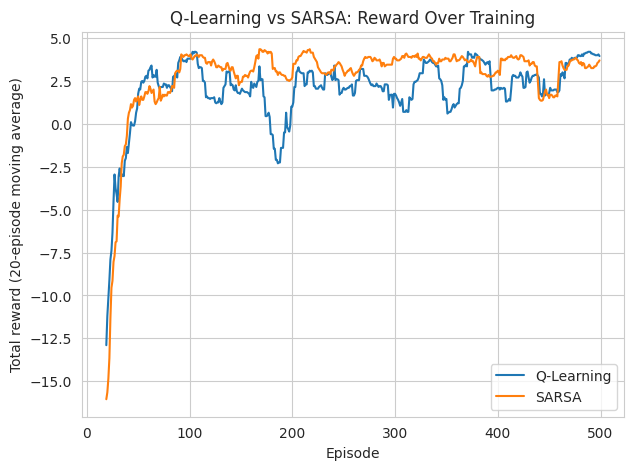

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [21]:
def train_sarsa(n_episodes=500, alpha=0.1, gamma=0.9, epsilon=0.2):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states}
    rewards_per_episode = []

    for ep in range(n_episodes):
        state = START
        action = epsilon_greedy(Q, state, epsilon)
        total_reward = 0
        done = False
        steps = 0
        while not done and steps < 50:
            next_state, reward, done = step(state, action)
            next_action = epsilon_greedy(Q, next_state, epsilon)
            # SARSA update: uses the NEXT action actually chosen (on-policy)
            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
            state, action = next_state, next_action
            total_reward += reward
            steps += 1
        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

np.random.seed(RANDOM_STATE)
Q_sarsa, sarsa_rewards = train_sarsa()

sarsa_policy = {s: ACTIONS[np.argmax([Q_sarsa[s][a] for a in ACTIONS])]
                for s in all_states if s not in (GOAL, TRAP)}
sarsa_values_grid = np.array([[max(Q_sarsa[(r, c)].values()) for c in range(GRID_SIZE)]
                               for r in range(GRID_SIZE)])

render_grid(values=sarsa_values_grid, policy=sarsa_policy, title="SARSA: Learned Values & Policy")

plt.plot(pd.Series(q_rewards).rolling(20).mean(), label="Q-Learning")
plt.plot(pd.Series(sarsa_rewards).rolling(20).mean(), label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Total reward (20-episode moving average)")
plt.title("Q-Learning vs SARSA: Reward Over Training")
plt.legend()
plt.show()


**🧪 Try it yourself:** compare the two policies near the TRAP cell — SARSA often routes further
around it than Q-Learning, because it accounts for its own exploration mistakes during learning.


### Monte Carlo Methods

Instead of updating after every single step (like Q-Learning/SARSA), **Monte Carlo** methods play
out a **full episode** first, then update state values using the *actual total reward received* from
that point onward. Simple, unbiased, but needs complete episodes (so it doesn't work for
never-ending tasks).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

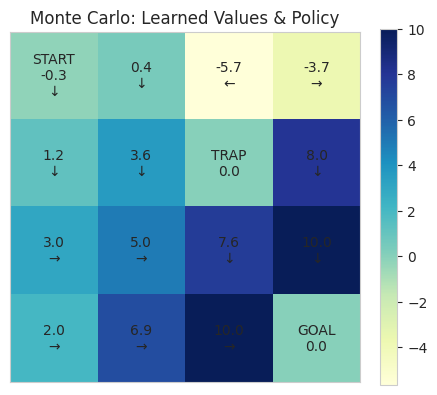

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
def generate_episode(policy_fn, epsilon=0.2):
    state = START
    episode = []
    done = False
    steps = 0
    while not done and steps < 50:
        action = policy_fn(state, epsilon)
        next_state, reward, done = step(state, action)
        episode.append((state, action, reward))
        state = next_state
        steps += 1
    return episode

def train_first_visit_mc(n_episodes=500, gamma=0.9, epsilon=0.2):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states}
    returns_sum = {s: {a: [] for a in ACTIONS} for s in all_states}

    def policy_fn(state, eps):
        return epsilon_greedy(Q, state, eps)

    for ep in range(n_episodes):
        episode = generate_episode(policy_fn, epsilon)
        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[state][action].append(G)
                Q[state][action] = np.mean(returns_sum[state][action])
    return Q

np.random.seed(RANDOM_STATE)
Q_mc = train_first_visit_mc()

mc_policy = {s: ACTIONS[np.argmax([Q_mc[s][a] for a in ACTIONS])]
             for s in all_states if s not in (GOAL, TRAP)}
mc_values_grid = np.array([[max(Q_mc[(r, c)].values()) for c in range(GRID_SIZE)]
                            for r in range(GRID_SIZE)])

render_grid(values=mc_values_grid, policy=mc_policy, title="Monte Carlo: Learned Values & Policy")


### A taste of Policy-Gradient Methods (REINFORCE)

Q-Learning/SARSA/Monte Carlo all learn **values**, then derive a policy from them. **REINFORCE**
instead directly learns a **policy** — a probability distribution over actions — and nudges it
toward actions that led to higher reward. This is the foundation that **Actor-Critic** and **A3C**
build on (by adding a learned value function to reduce variance in the updates).

To keep this runnable without a deep learning framework, here's REINFORCE on a **simplified 1-step
decision**: a 3-armed bandit (three slot machines with different hidden payout rates) — the same
core update rule scales up to full episodes and neural network policies in Actor-Critic/A3C.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

True payout rates: [0.3, 0.5, 0.8]
Learned action probabilities: [0.013 0.017 0.97 ]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

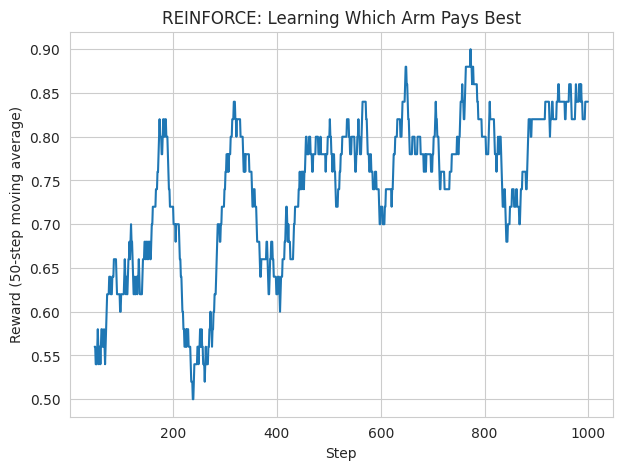

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
true_payout_rates = [0.3, 0.5, 0.8]  # hidden from the agent; arm 2 is best
n_arms = len(true_payout_rates)

theta = np.zeros(n_arms)  # policy logits
learning_rate = 0.1
n_steps = 1000
reward_history = []

np.random.seed(RANDOM_STATE)
for t in range(n_steps):
    # softmax policy
    probs = np.exp(theta) / np.sum(np.exp(theta))
    arm = np.random.choice(n_arms, p=probs)
    reward = 1 if np.random.rand() < true_payout_rates[arm] else 0

    # REINFORCE update: push up the log-probability of the chosen arm, scaled by reward
    grad_log_prob = -probs.copy()
    grad_log_prob[arm] += 1
    theta += learning_rate * reward * grad_log_prob

    reward_history.append(reward)

final_probs = np.exp(theta) / np.sum(np.exp(theta))
print("True payout rates:", true_payout_rates)
print("Learned action probabilities:", np.round(final_probs, 3))

plt.plot(pd.Series(reward_history).rolling(50).mean())
plt.xlabel("Step")
plt.ylabel("Reward (50-step moving average)")
plt.title("REINFORCE: Learning Which Arm Pays Best")
plt.show()


---
## ✅ Recap

**Module 3 — Unsupervised Learning:** we clustered synthetic customer data with K-Means (+ elbow
method), Hierarchical Clustering (+ dendrogram), DBSCAN (density-based, handles curved clusters),
and Gaussian Mixtures (soft clustering); reduced a 10-feature dataset to 2D with PCA and t-SNE, and
unrolled a 3D Swiss Roll with Isomap/LLE; then mined "if this, then that" shopping patterns with
Apriori and FP-Growth.

**Module 4 — Reinforcement Learning:** we built a GridWorld, solved it exactly with model-based
Value Iteration (using the Bellman equation), then learned it from scratch with model-free
Q-Learning, SARSA, and Monte Carlo — and got a first taste of policy-gradient learning with
REINFORCE on a multi-armed bandit.
